# 🧠 MobileNetV3 Small + SSD-Lite para ESP32-S3

**Objetivo**: Entrenar un modelo de detección de objetos ligero usando Transfer Learning con MobileNetV3 Small como backbone y cabezal SSD-Lite, optimizado para despliegue en ESP32-S3 (N16R8).

## Arquitectura

- **Backbone**: MobileNetV3 Small (minimalistic=True para compatibilidad TFLite)
- **Head**: SSD-Lite con convoluciones separables en profundidad
- **Clases**: 4 (door, footpath, obstacle, person)
- **Input**: 224×224×3 RGB

## Estrategia de Entrenamiento (2 Fases)

| Fase | Backbone | LR | Épocas | Objetivo |
|------|----------|----|---------| ---------|
| 1. Warm-up | 🔒 Congelado | 1e-3 | 15 | Entrenar solo el cabezal SSD-Lite |
| 2. Fine-tuning | 🔓 Últimas 30 capas | 1e-5 | 100 | Ajustar backbone + head con early stopping |

## Manejo de Desbalance

- **Focal Loss** (α=0.25, γ=2.0) para enfocar en ejemplos difíciles
- **Class Weights** calculados por frecuencia inversa

## 1. Setup y Configuración

In [2]:
# Imports y configuración inicial
import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Suprimir warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# TensorFlow
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

# Configurar memoria GPU (evitar OOM)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Memory growth habilitado para {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(f"⚠️ Error configurando GPU: {e}")

TensorFlow version: 2.16.2
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Memory growth habilitado para 1 GPU(s)


In [3]:
# Agregar paths al sistema
PROJECT_ROOT = Path.cwd().parent.parent  # TFM_UNIR
ING_MODELOS = PROJECT_ROOT / "02_ING_MODELOS"
ING_DATOS = PROJECT_ROOT / "01_ING_DATOS"

# Agregar módulos personalizados
sys.path.insert(0, str(ING_MODELOS))
sys.path.insert(0, str(ING_MODELOS / "src_mobilenet"))

print(f"📁 Project root: {PROJECT_ROOT}")
print(f"📁 ING_MODELOS: {ING_MODELOS}")
print(f"📁 ING_DATOS: {ING_DATOS}")

📁 Project root: /Users/admin/Documents/TFM_UNIR
📁 ING_MODELOS: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS
📁 ING_DATOS: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS


In [4]:
# Importar módulos personalizados de src_mobilenet
from src_mobilenet.utils_mobilenet_model import (
    build_mobilenetv3_ssd_lite,
    build_mobilenetv2_ssd_lite,
    print_model_summary,
)
from src_mobilenet.utils_mobilenet_data import (
    load_coco_annotations,
    compute_class_weights,
    generate_anchors,
    COCODataGenerator,
    compute_anchor_statistics,
)
from src_mobilenet.utils_mobilenet_losses import (
    focal_loss,
    binary_focal_loss,
    smooth_l1_loss,
    ssd_combined_loss,
)
from src_mobilenet.utils_mobilenet_train import (
    freeze_backbone,
    unfreeze_backbone_layers,
    create_callbacks,
    train_two_phase,
    save_training_history,
    plot_training_history,
    LearningRateLogger,
)
from src_mobilenet.utils_mobilenet_export import (
    export_tflite,
    export_tflite_int8,
    export_for_esp32,
    estimate_model_size,
    verify_tflite_model,
)

print("✅ Módulos de src_mobilenet importados correctamente")

✅ Módulos de src_mobilenet importados correctamente


In [5]:
# ============================================
# CONFIGURACIÓN DE RUTAS Y PARÁMETROS
# ============================================

# --- Rutas del Dataset ---
TRAIN_IMG_DIR = ING_DATOS / "Dataset/train/augmented2_images"
TRAIN_JSON = ING_DATOS / "Dataset/train/augmented2_images/train_final2.json"

VAL_IMG_DIR = ING_DATOS / "Dataset/valid"
VAL_JSON = ING_DATOS / "Dataset/valid/val_final.json"

TEST_IMG_DIR = ING_DATOS / "Dataset/test"
TEST_JSON = ING_DATOS / "Dataset/test/test_final.json"

# --- Rutas de Salida ---
REPORTS_DIR = ING_MODELOS / "reports"
FIGURES_DIR = ING_MODELOS / "reports/figures"
MODELS_DIR = ING_MODELOS / "models"
CHECKPOINTS_DIR = ING_MODELOS / "models/checkpoints"
EXPORT_DIR = ING_MODELOS / "models/final_export"
LOGS_DIR = ING_MODELOS / "logs"
DATASETS_DIR = ING_MODELOS / "datasets/mobilenet"

# Crear directorios
for d in [REPORTS_DIR, FIGURES_DIR, MODELS_DIR, CHECKPOINTS_DIR, EXPORT_DIR, LOGS_DIR, DATASETS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- Parámetros del Modelo ---
IMG_SIZE = 224
NUM_CLASSES = 4
CLASS_NAMES = ["door", "footpath", "obstacle", "person"]  # Orden por category_id

# --- Parámetros de Anchors ---
FEATURE_MAP_SIZE = 7  # 224 / 32
ANCHOR_SCALES = [0.1, 0.2, 0.4]
ANCHOR_RATIOS = [0.5, 1.0, 2.0]
NUM_ANCHORS_PER_CELL = len(ANCHOR_SCALES) * len(ANCHOR_RATIOS)  # 9
IOU_THRESHOLD = 0.35

# --- Hiperparámetros de Entrenamiento ---
BATCH_SIZE = 32

# Fase 1: Warm-up
PHASE1_EPOCHS = 15
PHASE1_LR = 1e-3

# Fase 2: Fine-tuning  
PHASE2_EPOCHS = 100
PHASE2_LR = 1e-5
NUM_LAYERS_TO_UNFREEZE = 30

# Callbacks
PATIENCE_REDUCE_LR = 5
PATIENCE_EARLY_STOP = 15
REDUCE_LR_FACTOR = 0.2

# Loss weights
CLS_WEIGHT = 1.0
OBJ_WEIGHT = 1.0
BBOX_WEIGHT = 2.0

# Focal Loss params
FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0

# Nombre del experimento
MODEL_NAME = "mobilenetv3_ssdlite_v1"

print("✅ Configuración cargada")
print(f"   Dataset train: {TRAIN_IMG_DIR}")
print(f"   Modelo: {MODEL_NAME}")
print(f"   Anchors por celda: {NUM_ANCHORS_PER_CELL}")

✅ Configuración cargada
   Dataset train: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/train/augmented2_images
   Modelo: mobilenetv3_ssdlite_v1
   Anchors por celda: 9


## 2. Cargar y Analizar Dataset

In [6]:
# Cargar anotaciones COCO
print("📂 Cargando dataset de entrenamiento...")
train_data, cat_id_to_name, cat_id_to_idx = load_coco_annotations(
    json_path=str(TRAIN_JSON),
    image_dir=str(TRAIN_IMG_DIR),
)

print("\n📂 Cargando dataset de validación...")
val_data, _, _ = load_coco_annotations(
    json_path=str(VAL_JSON),
    image_dir=str(VAL_IMG_DIR),
)

print("\n📂 Cargando dataset de test...")
test_data, _, _ = load_coco_annotations(
    json_path=str(TEST_JSON),
    image_dir=str(TEST_IMG_DIR),
)

print(f"\n📊 Resumen del Dataset:")
print(f"   Train: {len(train_data)} imágenes")
print(f"   Val:   {len(val_data)} imágenes")
print(f"   Test:  {len(test_data)} imágenes")

📂 Cargando dataset de entrenamiento...
✅ Loaded 1371 images with annotations
   Categories: {2: 'door', 5: 'footpath', 6: 'obstacle', 7: 'person'}
   Class mapping: {2: 0, 5: 1, 6: 2, 7: 3}

📂 Cargando dataset de validación...
✅ Loaded 85 images with annotations
   Categories: {2: 'door', 5: 'footpath', 6: 'obstacle', 7: 'person'}
   Class mapping: {2: 0, 5: 1, 6: 2, 7: 3}

📂 Cargando dataset de test...
✅ Loaded 84 images with annotations
   Categories: {2: 'door', 5: 'footpath', 6: 'obstacle', 7: 'person'}
   Class mapping: {2: 0, 5: 1, 6: 2, 7: 3}

📊 Resumen del Dataset:
   Train: 1371 imágenes
   Val:   85 imágenes
   Test:  84 imágenes


In [7]:
# Calcular pesos de clase para manejar desbalance
class_weights = compute_class_weights(train_data, NUM_CLASSES, method="inverse_freq")

# Convertir a tensor para la loss function
class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)
print(f"\n⚖️ Class weights tensor: {class_weights}")


📊 Class distribution and weights (inverse_freq):
   Class 0:   389 samples, weight=2.080
   Class 1:   784 samples, weight=1.032
   Class 2:  1648 samples, weight=0.491
   Class 3:   415 samples, weight=1.949
   Total: 3236 samples

⚖️ Class weights tensor: [2.0796914  1.0318878  0.49089807 1.9493976 ]


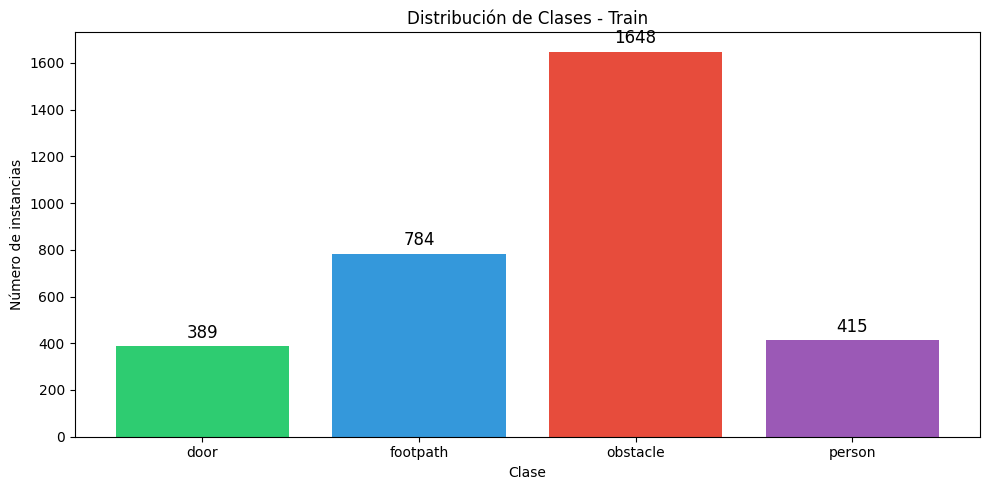

In [8]:
# Visualizar distribución de clases
from collections import Counter

def plot_class_distribution(data_list, title="Class Distribution"):
    """Visualizar distribución de clases."""
    class_counts = Counter()
    for img in data_list:
        for cls in img["classes"]:
            class_counts[cls] += 1
    
    classes = list(range(NUM_CLASSES))
    counts = [class_counts.get(c, 0) for c in classes]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(CLASS_NAMES, counts, color=['#2ecc71', '#3498db', '#e74c3c', '#9b59b6'])
    ax.set_xlabel('Clase')
    ax.set_ylabel('Número de instancias')
    ax.set_title(title)
    
    # Agregar etiquetas en las barras
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax.annotate(f'{count}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=12)
    
    plt.tight_layout()
    return fig

fig = plot_class_distribution(train_data, "Distribución de Clases - Train")
fig.savefig(FIGURES_DIR / "mobilenet_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## 3. Generar Anchors y Data Generators

In [9]:
# Generar anchors para SSD
anchors = generate_anchors(
    feature_map_size=FEATURE_MAP_SIZE,
    scales=ANCHOR_SCALES,
    aspect_ratios=ANCHOR_RATIOS,
)

print(f"📦 Anchors generados: {anchors.shape}")
print(f"   Feature map: {FEATURE_MAP_SIZE}×{FEATURE_MAP_SIZE}")
print(f"   Anchors por celda: {NUM_ANCHORS_PER_CELL}")
print(f"   Total anchors: {len(anchors)}")

# Estadísticas de los anchors
print(f"\n   Tamaños de anchors (w×h):")
for scale in ANCHOR_SCALES:
    for ratio in ANCHOR_RATIOS:
        w = scale * np.sqrt(ratio)
        h = scale / np.sqrt(ratio)
        print(f"      scale={scale}, ratio={ratio:.1f} → w={w:.3f}, h={h:.3f}")

📦 Anchors generados: (441, 4)
   Feature map: 7×7
   Anchors por celda: 9
   Total anchors: 441

   Tamaños de anchors (w×h):
      scale=0.1, ratio=0.5 → w=0.071, h=0.141
      scale=0.1, ratio=1.0 → w=0.100, h=0.100
      scale=0.1, ratio=2.0 → w=0.141, h=0.071
      scale=0.2, ratio=0.5 → w=0.141, h=0.283
      scale=0.2, ratio=1.0 → w=0.200, h=0.200
      scale=0.2, ratio=2.0 → w=0.283, h=0.141
      scale=0.4, ratio=0.5 → w=0.283, h=0.566
      scale=0.4, ratio=1.0 → w=0.400, h=0.400
      scale=0.4, ratio=2.0 → w=0.566, h=0.283


In [10]:
# Verificar matching de anchors con el dataset
anchor_stats = compute_anchor_statistics(train_data, anchors, iou_threshold=IOU_THRESHOLD)


📊 Anchor Matching Statistics:
   Total GT boxes: 3236
   Matched GT boxes (IoU≥0.35): 2382 (73.6%)
   Avg max IoU per GT: 0.464
   Min max IoU: 0.091
   Avg positive anchors/image: 13.4


In [11]:
# Crear generadores de datos
print("🔧 Creando generadores de datos...")

train_gen = COCODataGenerator(
    images_data=train_data,
    anchors=anchors,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    iou_threshold=IOU_THRESHOLD,
    augment=True,  # Data augmentation para train
    shuffle=True,
)

val_gen = COCODataGenerator(
    images_data=val_data,
    anchors=anchors,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    iou_threshold=IOU_THRESHOLD,
    augment=False,
    shuffle=False,
)

test_gen = COCODataGenerator(
    images_data=test_data,
    anchors=anchors,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    iou_threshold=IOU_THRESHOLD,
    augment=False,
    shuffle=False,
)

print(f"✅ Generadores creados:")
print(f"   Train: {len(train_gen)} batches × {BATCH_SIZE} = ~{len(train_gen)*BATCH_SIZE} samples")
print(f"   Val:   {len(val_gen)} batches")
print(f"   Test:  {len(test_gen)} batches")

🔧 Creando generadores de datos...
✅ Generadores creados:
   Train: 43 batches × 32 = ~1376 samples
   Val:   3 batches
   Test:  3 batches


In [12]:
# Verificar un batch
sample_batch_x, sample_batch_y = train_gen[0]

print(f"📊 Verificación de batch:")
print(f"   X shape: {sample_batch_x.shape}")
print(f"   Y objectness shape: {sample_batch_y['objectness'].shape}")
print(f"   Y class_out shape: {sample_batch_y['class_out'].shape}")
print(f"   Y bbox_out shape: {sample_batch_y['bbox_out'].shape}")

# Estadísticas de positivos
positives_per_sample = sample_batch_y['objectness'].sum(axis=(1, 2))
print(f"\n   Positivos por imagen: min={positives_per_sample.min():.0f}, max={positives_per_sample.max():.0f}, mean={positives_per_sample.mean():.1f}")

📊 Verificación de batch:
   X shape: (32, 224, 224, 3)
   Y objectness shape: (32, 441, 1)
   Y class_out shape: (32, 441, 4)
   Y bbox_out shape: (32, 441, 4)

   Positivos por imagen: min=1, max=40, mean=14.2


## 4. Construir Modelo MobileNetV3 + SSD-Lite

In [13]:
# Construir modelo MobileNetV3 Small + SSD-Lite
# Nota: minimalistic=True usa ReLU en lugar de hard-swish (mejor para ESP32-S3)

model = build_mobilenetv3_ssd_lite(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES,
    num_anchors_per_cell=NUM_ANCHORS_PER_CELL,
    alpha=1.0,              # Width multiplier
    minimalistic=True,      # ReLU instead of hard-swish (ESP32 compatible)
    feature_channels=128,   # SSD head channels
    use_batchnorm=True,
    dropout_rate=0.2,
    model_name=MODEL_NAME,
)

print_model_summary(model)


Model: mobilenetv3_ssdlite_v1
Total params: 551,737
Trainable params: 537,705
Non-trainable params: 14,032
Estimated size (float32): 2.10 MB
Estimated size (int8): 0.53 MB



In [14]:
# Alternativa: MobileNetV2 (probado en ESP32-S3, más ligero)
# Descomentar para usar MobileNetV2 en lugar de MobileNetV3

# model = build_mobilenetv2_ssd_lite(
#     input_shape=(IMG_SIZE, IMG_SIZE, 3),
#     num_classes=NUM_CLASSES,
#     num_anchors_per_cell=NUM_ANCHORS_PER_CELL,
#     alpha=0.35,  # Más pequeño para ESP32-S3 (~250KB)
#     feature_channels=128,
#     use_batchnorm=True,
#     dropout_rate=0.2,
#     model_name="mobilenetv2_ssdlite_v1",
# )

In [15]:
# Visualizar arquitectura del modelo
model.summary(show_trainable=True, expand_nested=False)

Model: "mobilenetv3_ssdlite_v1"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer       │ (None, 224,     │         0 │ -              │   -   │
│ (InputLayer)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ conv (Conv2D)     │ (None, 112,     │       432 │ input_layer[0… │   Y   │
│                   │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ conv_bn           │ (None, 112,     │        64 │ conv[0][0]     │   Y   │
│ (BatchNormalizat… │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ re_lu (ReLU)      │ (None, 112,     │         0 │ conv_bn[0][0]  │   -   │
│                   │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 113,     │         0 │ re_lu[0][0]    │   -   │
│ (ZeroPadding2D)   │ 113, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 56, 56,  │       144 │ expanded_conv… │   Y   │
│ (DepthwiseConv2D) │ 16)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 56, 56,  │        64 │ expanded_conv… │   Y   │
│ (BatchNormalizat… │ 16)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ re_lu_1 (ReLU)    │ (None, 56, 56,  │         0 │ expanded_conv… │   -   │
│                   │ 16)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 56, 56,  │       256 │ re_lu_1[0][0]  │   Y   │
│ (Conv2D)          │ 16)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 56, 56,  │        64 │ expanded_conv… │   Y   │
│ (BatchNormalizat… │ 16)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_1_… │ (None, 56, 56,  │     1,152 │ expanded_conv… │   Y   │
│ (Conv2D)          │ 72)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_1_… │ (None, 56, 56,  │       288 │ expanded_conv… │   Y   │
│ (BatchNormalizat… │ 72)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ re_lu_2 (ReLU)    │ (None, 56, 56,  │         0 │ expanded_conv… │   -   │
│                   │ 72)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_1_… │ (None, 57, 57,  │         0 │ re_lu_2[0][0]  │   -   │
│ (ZeroPadding2D)   │ 72)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_1_… │ (None, 28, 28,  │       648 │ expanded_conv… │   Y   │
│ (DepthwiseConv2D) │ 72)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_1_… │ (None, 28, 28,  │       288 │ expanded_conv… │   Y   │
│ (BatchNormalizat… │ 72)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ re_lu_3 (ReLU)    │ (None, 28, 28,  │         0 │ expanded_conv… │   - 

 Total params: 551,737 (2.10 MB)

 Trainable params: 537,705 (2.05 MB)

 Non-trainable params: 14,032 (54.81 KB)

In [16]:
# Estimar tamaño del modelo para ESP32-S3
model_sizes = estimate_model_size(model)


📊 Model Size Estimates:
   Total parameters: 551,737
   Float32: 2155.2 KB (2.10 MB)
   Float16: 1077.6 KB (1.05 MB)
   INT8:    538.8 KB (0.53 MB)
   ✅ INT8 model fits ESP32-S3 flash limit (1024 KB)


## 5. Configurar Losses y Métricas

In [17]:
# Configurar funciones de pérdida con Focal Loss
# Focal Loss es clave para manejar el desbalance de clases en detección de objetos

loss_config = ssd_combined_loss(
    cls_weight=CLS_WEIGHT,
    obj_weight=OBJ_WEIGHT,
    bbox_weight=BBOX_WEIGHT,
    focal_alpha=FOCAL_ALPHA,
    focal_gamma=FOCAL_GAMMA,
    smooth_l1_delta=1.0,
    class_weights=class_weights_tensor,  # Pesos de clase calculados
    use_giou=False,  # Smooth L1 por defecto, cambiar a True para GIoU
)

losses = loss_config["losses"]
loss_weights = loss_config["weights"]

print("📉 Funciones de pérdida configuradas:")
print(f"   Objectness: Binary Focal Loss (α={FOCAL_ALPHA}, γ={FOCAL_GAMMA}) × {OBJ_WEIGHT}")
print(f"   Classification: Focal Loss (α={FOCAL_ALPHA}, γ={FOCAL_GAMMA}) × {CLS_WEIGHT}")
print(f"   Bounding Box: Smooth L1 Loss × {BBOX_WEIGHT}")
print(f"   Class weights: {class_weights}")

📉 Funciones de pérdida configuradas:
   Objectness: Binary Focal Loss (α=0.25, γ=2.0) × 1.0
   Classification: Focal Loss (α=0.25, γ=2.0) × 1.0
   Bounding Box: Smooth L1 Loss × 2.0
   Class weights: [2.0796914  1.0318878  0.49089807 1.9493976 ]


## 6. Entrenamiento Fase 1: Warm-up (Backbone Congelado)

En esta fase solo entrenamos el cabezal SSD-Lite. El backbone MobileNetV3 permanece congelado con los pesos de ImageNet.

In [18]:
# FASE 1: Congelar backbone, entrenar solo el cabezal SSD-Lite
print("\n" + "="*70)
print("🔒 FASE 1: WARM-UP - Backbone Congelado")
print("="*70)

# Congelar todas las capas del backbone
freeze_backbone(model)

# Compilar modelo para Fase 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=PHASE1_LR),
    loss=losses,
    loss_weights=loss_weights,
    metrics={
        "objectness": ["binary_accuracy"],
        "class_out": ["categorical_accuracy"],
    }
)

print(f"\n📋 Configuración Fase 1:")
print(f"   Learning Rate: {PHASE1_LR}")
print(f"   Épocas: {PHASE1_EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")


🔒 FASE 1: WARM-UP - Backbone Congelado
🔒 Frozen 103 backbone layers
   Trainable params: 108,817 / 551,737 (19.7%)

📋 Configuración Fase 1:
   Learning Rate: 0.001
   Épocas: 15
   Batch Size: 32


In [19]:
# Callbacks para Fase 1
phase1_callbacks = create_callbacks(
    checkpoint_dir=str(CHECKPOINTS_DIR),
    log_dir=str(LOGS_DIR),
    model_name=f"{MODEL_NAME}_phase1",
    monitor="val_loss",
    patience_reduce_lr=PATIENCE_REDUCE_LR,
    patience_early_stop=PHASE1_EPOCHS,  # Sin early stopping en fase 1
    reduce_lr_factor=REDUCE_LR_FACTOR,
)

# Agregar logger de learning rate
lr_logger = LearningRateLogger()
phase1_callbacks.append(lr_logger)

📋 Created 5 callbacks:
   Checkpoint: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/mobilenetv3_ssdlite_v1_phase1_best.keras
   Logs: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/mobilenetv3_ssdlite_v1_phase1_history.csv
   Monitor: val_loss
   ReduceLR patience: 5, factor: 0.2
   EarlyStopping patience: 15


In [20]:
# Entrenar Fase 1
print("\n🚀 Iniciando entrenamiento Fase 1...")

history_phase1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=PHASE1_EPOCHS,
    callbacks=phase1_callbacks,
    verbose=1,
)

print("\n✅ Fase 1 completada")


🚀 Iniciando entrenamiento Fase 1...
Epoch 1/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - bbox_out_loss: 0.1372 - class_out_categorical_accuracy: 0.1054 - class_out_loss: 0.8320 - loss: 1.2751 - objectness_binary_accuracy: 0.6195 - objectness_loss: 0.1738
Epoch 1: val_loss improved from None to 0.71809, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/mobilenetv3_ssdlite_v1_phase1_best.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 179ms/step - bbox_out_loss: 0.1121 - class_out_categorical_accuracy: 0.0963 - class_out_loss: 0.5046 - loss: 0.8306 - objectness_binary_accuracy: 0.7621 - objectness_loss: 0.1063 - val_bbox_out_loss: 0.0785 - val_class_out_categorical_accuracy: 0.1281 - val_class_out_loss: 0.4707 - val_loss: 0.7181 - val_objectness_binary_accuracy: 0.9714 - val_objectness_loss: 0.0859 - learning_rate: 0.0010 - lr: 0.0010
Epoch 2/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - bbox_out_loss: 0.0717 - class_out_categorical_accuracy: 0.0847 - class_out_loss:

💾 Saved training history to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/mobilenetv3_ssdlite_v1_phase1_history.csv
📊 Saved training plot to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/mobilenetv3_ssdlite_v1_phase1_curves.png


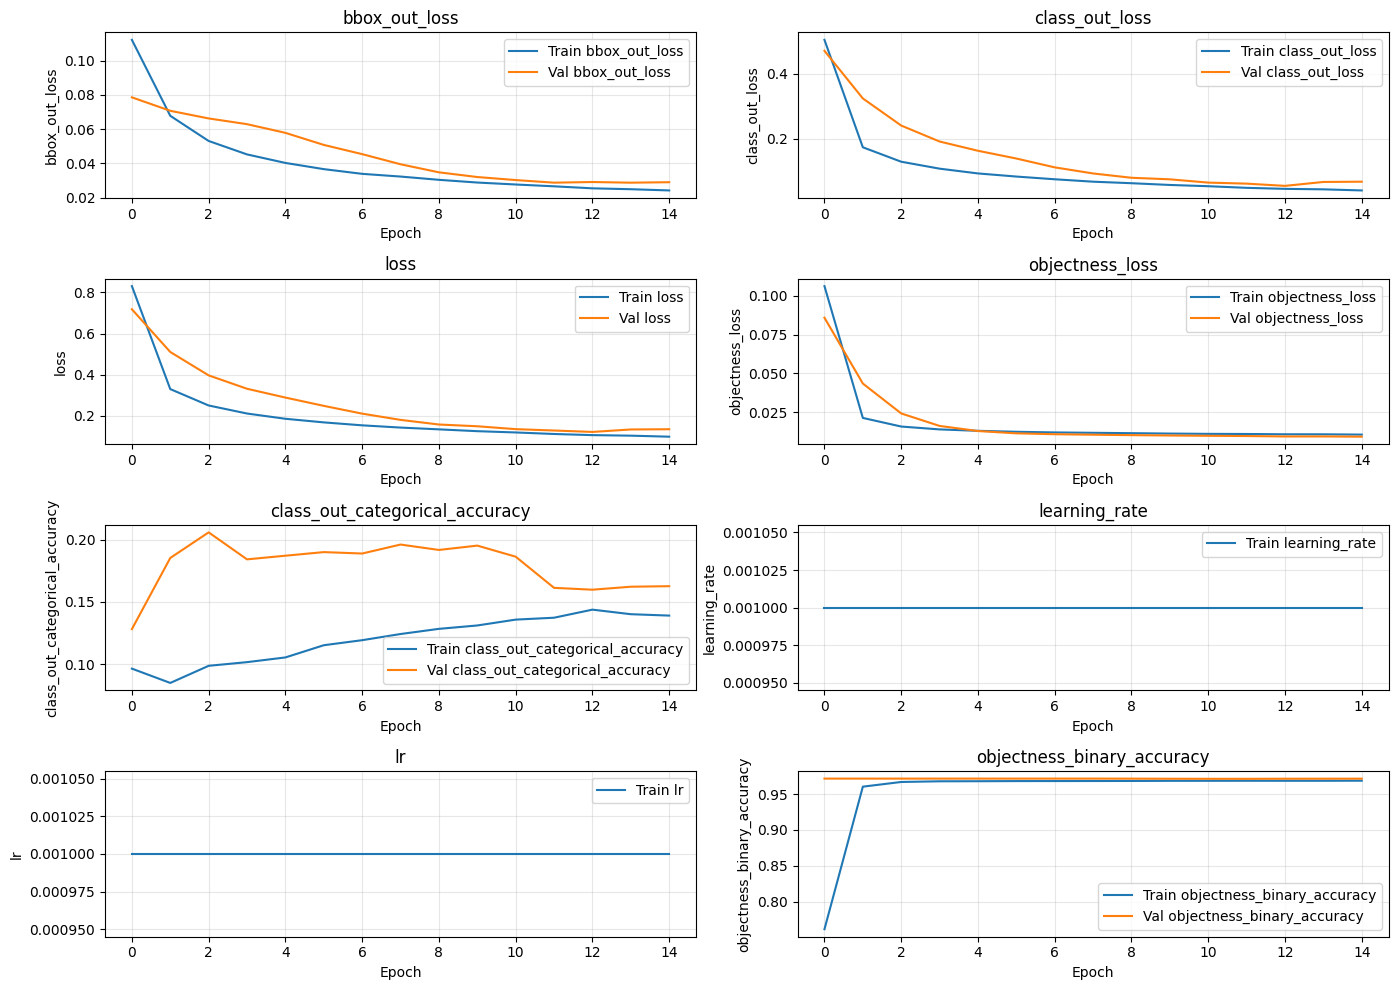

In [21]:
# Guardar historial Fase 1
df_phase1 = save_training_history(
    history_phase1, 
    str(LOGS_DIR / f"{MODEL_NAME}_phase1_history.csv")
)

# Visualizar progreso Fase 1
plot_training_history(history_phase1, output_path=str(FIGURES_DIR / f"{MODEL_NAME}_phase1_curves.png"))

## 7. Entrenamiento Fase 2: Fine-Tuning (Backbone Parcialmente Descongelado)

Descongelamos las últimas capas del backbone MobileNetV3 para que aprenda características específicas de nuestro dataset. **Learning rate muy bajo** para no destruir los pesos pre-entrenados.

In [22]:
# FASE 2: Descongelar últimas capas del backbone
print("\n" + "="*70)
print("🔓 FASE 2: FINE-TUNING - Backbone Parcialmente Descongelado")
print("="*70)

# Descongelar últimas N capas
unfreeze_backbone_layers(model, num_layers_to_unfreeze=NUM_LAYERS_TO_UNFREEZE)

# Recompilar con LR muy bajo (CRÍTICO)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=PHASE2_LR),
    loss=losses,
    loss_weights=loss_weights,
    metrics={
        "objectness": ["binary_accuracy"],
        "class_out": ["categorical_accuracy"],
    }
)

print(f"\n📋 Configuración Fase 2:")
print(f"   Learning Rate: {PHASE2_LR} (muy bajo para no destruir pesos)")
print(f"   Épocas máximas: {PHASE2_EPOCHS}")
print(f"   Early Stopping patience: {PATIENCE_EARLY_STOP}")
print(f"   ReduceLR patience: {PATIENCE_REDUCE_LR}")


🔓 FASE 2: FINE-TUNING - Backbone Parcialmente Descongelado
🔓 Unfroze last 30 layers
   Trainable params: 221,905 / 551,737 (40.2%)

📋 Configuración Fase 2:
   Learning Rate: 1e-05 (muy bajo para no destruir pesos)
   Épocas máximas: 100
   Early Stopping patience: 15
   ReduceLR patience: 5


In [23]:
# Callbacks para Fase 2 (con Early Stopping activo)
phase2_callbacks = create_callbacks(
    checkpoint_dir=str(CHECKPOINTS_DIR),
    log_dir=str(LOGS_DIR),
    model_name=f"{MODEL_NAME}_phase2",
    monitor="val_loss",
    patience_reduce_lr=PATIENCE_REDUCE_LR,
    patience_early_stop=PATIENCE_EARLY_STOP,
    reduce_lr_factor=REDUCE_LR_FACTOR,
)

# Agregar logger de learning rate
lr_logger_2 = LearningRateLogger()
phase2_callbacks.append(lr_logger_2)

📋 Created 5 callbacks:
   Checkpoint: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/mobilenetv3_ssdlite_v1_phase2_best.keras
   Logs: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/mobilenetv3_ssdlite_v1_phase2_history.csv
   Monitor: val_loss
   ReduceLR patience: 5, factor: 0.2
   EarlyStopping patience: 15


In [24]:
# Entrenar Fase 2
print("\n🚀 Iniciando entrenamiento Fase 2 (Fine-tuning)...")
print("   Esto puede tomar tiempo. Early stopping detendrá si no mejora.")

history_phase2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=PHASE2_EPOCHS,
    callbacks=phase2_callbacks,
    verbose=1,
)

print("\n✅ Fase 2 completada")


🚀 Iniciando entrenamiento Fase 2 (Fine-tuning)...
   Esto puede tomar tiempo. Early stopping detendrá si no mejora.
Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - bbox_out_loss: 0.0282 - class_out_categorical_accuracy: 0.1385 - class_out_loss: 0.0595 - loss: 0.1266 - objectness_binary_accuracy: 0.9694 - objectness_loss: 0.0107
Epoch 1: val_loss improved from None to 0.12396, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/mobilenetv3_ssdlite_v1_phase2_best.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 210ms/step - bbox_out_loss: 0.0277 - class_out_categorical_accuracy: 0.1397 - class_out_loss: 0.0576 - loss: 0.1238 - objectness_binary_accuracy: 0.9683 - objectness_loss: 0.0109 - val_bbox_out_loss: 0.0285 - val_class_out_categorical_accuracy: 0.1631 - val_class_out_loss: 0.0571 - val_loss: 0.1240 - val_objectness_binary_accuracy: 0.9714 - val_objectness_loss: 0.0093 - learning_rate: 1.0000e-05 - lr: 1.0000e-05
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8

💾 Saved training history to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/mobilenetv3_ssdlite_v1_phase2_history.csv
📊 Saved training plot to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/mobilenetv3_ssdlite_v1_phase2_curves.png


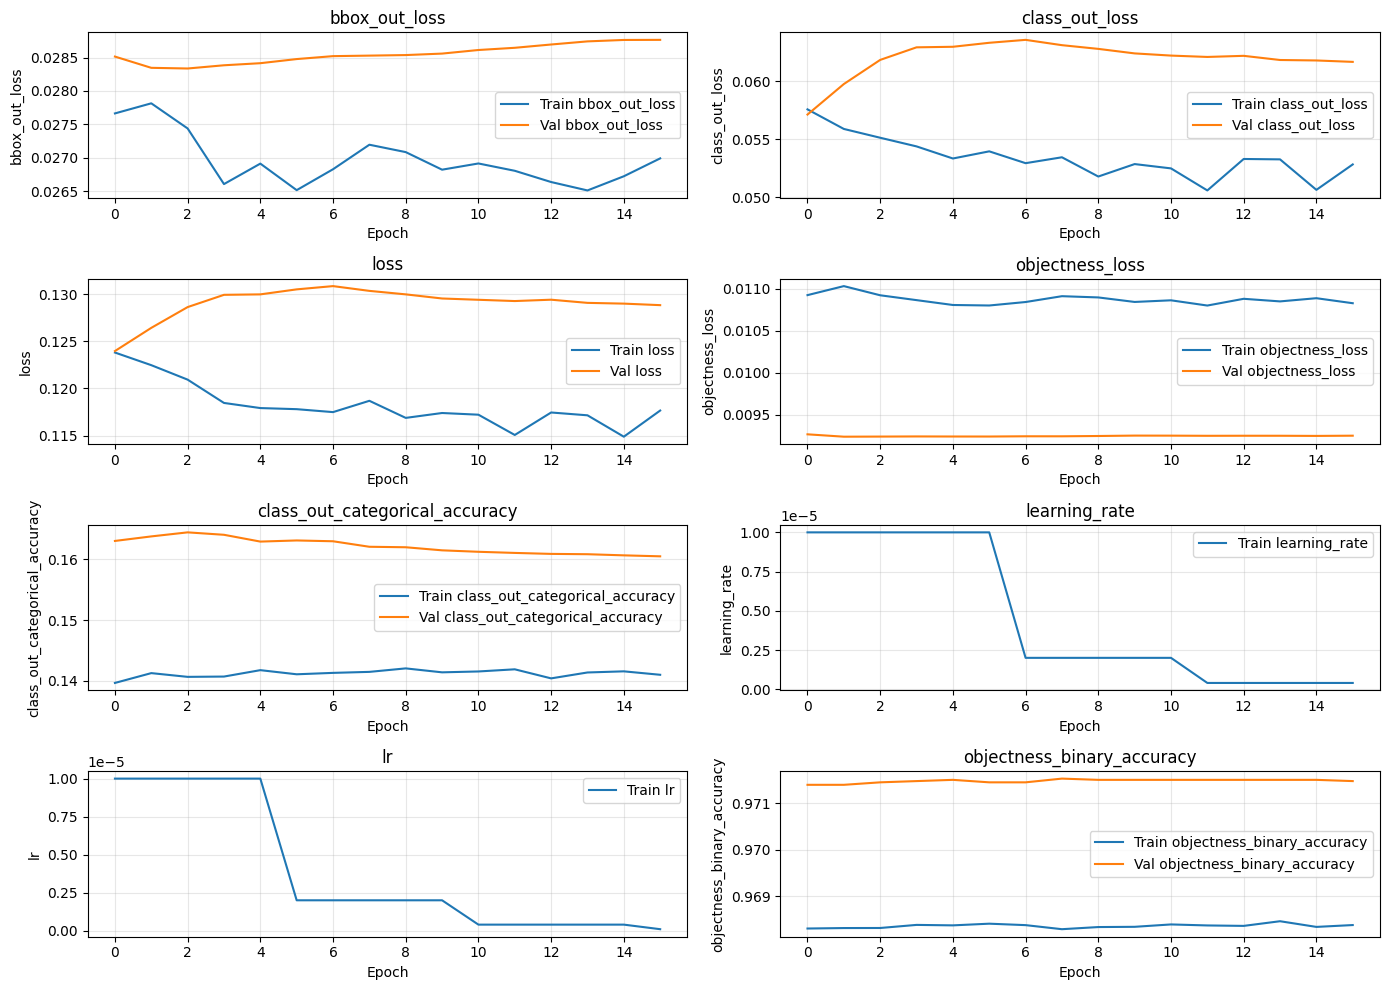

In [25]:
# Guardar historial Fase 2
df_phase2 = save_training_history(
    history_phase2,
    str(LOGS_DIR / f"{MODEL_NAME}_phase2_history.csv")
)

# Visualizar progreso Fase 2
plot_training_history(history_phase2, output_path=str(FIGURES_DIR / f"{MODEL_NAME}_phase2_curves.png"))

## 8. Evaluación del Modelo

In [26]:
# Cargar mejor modelo guardado
best_model_path = CHECKPOINTS_DIR / f"{MODEL_NAME}_phase2_best.keras"

if best_model_path.exists():
    print(f"📂 Cargando mejor modelo desde: {best_model_path}")
    model = tf.keras.models.load_model(
        best_model_path,
        custom_objects={
            "loss_fn": binary_focal_loss(FOCAL_ALPHA, FOCAL_GAMMA),
        },
        compile=False
    )
    # Recompilar
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=PHASE2_LR),
        loss=losses,
        loss_weights=loss_weights,
        metrics={
            "objectness": ["binary_accuracy"],
            "class_out": ["categorical_accuracy"],
        }
    )
    print("✅ Mejor modelo cargado")
else:
    print("⚠️ No se encontró checkpoint, usando modelo actual")

📂 Cargando mejor modelo desde: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/mobilenetv3_ssdlite_v1_phase2_best.keras
✅ Mejor modelo cargado


In [27]:
# Evaluar en conjunto de validación
print("\n📊 Evaluación en conjunto de VALIDACIÓN:")
val_results = model.evaluate(val_gen, verbose=1)

print("\n📊 Evaluación en conjunto de TEST:")
test_results = model.evaluate(test_gen, verbose=1)

# Mostrar métricas
metric_names = model.metrics_names
print(f"\n{'='*50}")
print("RESUMEN DE MÉTRICAS")
print(f"{'='*50}")
print(f"{'Métrica':<35} {'Val':>10} {'Test':>10}")
print(f"{'-'*50}")
for name, val, test in zip(metric_names, val_results, test_results):
    print(f"{name:<35} {val:>10.4f} {test:>10.4f}")


📊 Evaluación en conjunto de VALIDACIÓN:
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 391ms/step - bbox_out_loss: 0.0285 - class_out_categorical_accuracy: 0.1631 - class_out_loss: 0.0571 - loss: 0.1240 - objectness_binary_accuracy: 0.9714 - objectness_loss: 0.0093

📊 Evaluación en conjunto de TEST:
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 454ms/step - bbox_out_loss: 0.0267 - class_out_categorical_accuracy: 0.1741 - class_out_loss: 0.0737 - loss: 0.1386 - objectness_binary_accuracy: 0.9636 - objectness_loss: 0.0113

RESUMEN DE MÉTRICAS
Métrica                                    Val       Test
--------------------------------------------------
loss                                    0.1240     0.1386
compile_metrics                         0.0093     0.0113
objectness_loss                         0.0571     0.0737
class_out_loss                          0.0285     0.0267
bbox_out_loss                           0.1631     0.1741


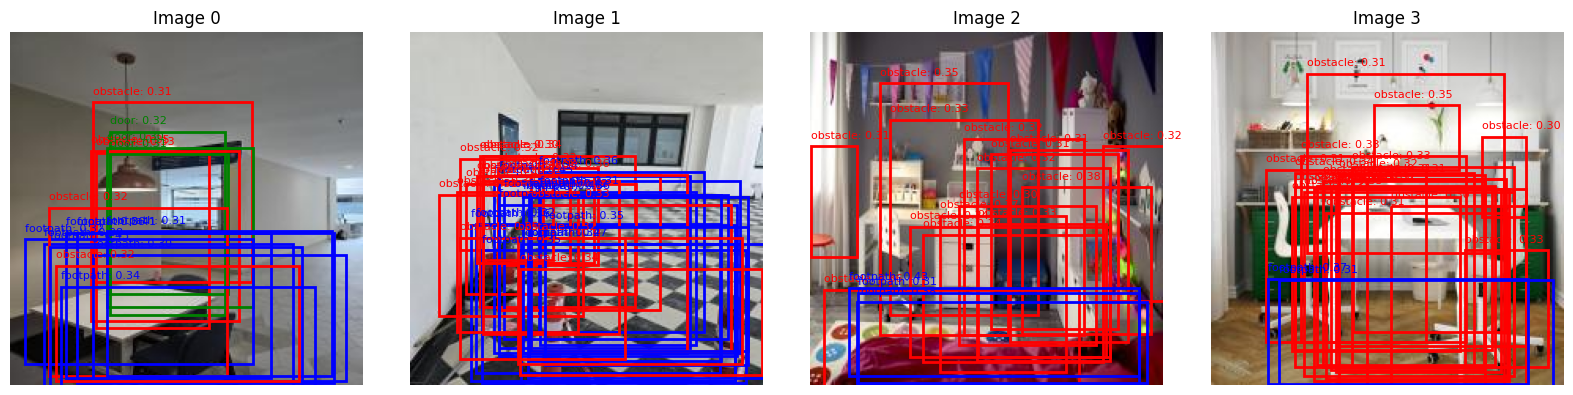

In [28]:
# Visualizar predicciones en algunas imágenes de test
import cv2

def visualize_predictions(model, images_data, anchors, num_samples=4, conf_threshold=0.5):
    """Visualizar predicciones del modelo."""
    fig, axes = plt.subplots(1, num_samples, figsize=(4*num_samples, 4))
    
    for idx, ax in enumerate(axes):
        if idx >= len(images_data):
            break
        
        img_data = images_data[idx]
        img = cv2.imread(img_data["path"])
        img = cv2.resize(img, (224, 224))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_input = img.astype(np.float32) / 255.0
        
        # Predicción
        outputs = model.predict(np.expand_dims(img_input, 0), verbose=0)
        
        obj_pred = outputs["objectness"][0]  # (num_anchors, 1)
        cls_pred = outputs["class_out"][0]   # (num_anchors, num_classes)
        bbox_pred = outputs["bbox_out"][0]   # (num_anchors, 4)
        
        ax.imshow(img)
        
        # Dibujar predicciones con alta confianza
        for a_idx in range(len(anchors)):
            obj_conf = obj_pred[a_idx, 0]
            if obj_conf > conf_threshold:
                cls_idx = np.argmax(cls_pred[a_idx])
                cls_conf = cls_pred[a_idx, cls_idx]
                
                xc, yc, w, h = bbox_pred[a_idx]
                x1 = int((xc - w/2) * 224)
                y1 = int((yc - h/2) * 224)
                x2 = int((xc + w/2) * 224)
                y2 = int((yc + h/2) * 224)
                
                colors = ['green', 'blue', 'red', 'purple']
                rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                     fill=False, color=colors[cls_idx], linewidth=2)
                ax.add_patch(rect)
                ax.text(x1, y1-5, f"{CLASS_NAMES[cls_idx]}: {obj_conf:.2f}", 
                       color=colors[cls_idx], fontsize=8)
        
        ax.set_title(f"Image {idx}")
        ax.axis('off')
    
    plt.tight_layout()
    return fig

fig = visualize_predictions(model, test_data, anchors, num_samples=4, conf_threshold=0.3)
fig.savefig(FIGURES_DIR / f"{MODEL_NAME}_predictions.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Exportar a TFLite para ESP32-S3

In [29]:
# Guardar modelo Keras final
model_keras_path = EXPORT_DIR / f"{MODEL_NAME}_final.keras"
model.save(model_keras_path)
print(f"💾 Modelo Keras guardado: {model_keras_path}")

💾 Modelo Keras guardado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/final_export/mobilenetv3_ssdlite_v1_final.keras


In [30]:
# ============================================
# EXPORTACIÓN TFLite PARA ESP32-S3
# ============================================
# 
# IMPORTANTE: La conversión TFLite puede fallar en el notebook por problemas de memoria.
# Se recomienda ejecutar el script externo para máxima estabilidad.

import subprocess
import sys

# Verificar que el modelo Keras existe
model_keras_path = EXPORT_DIR / f"{MODEL_NAME}_final.keras"
int8_tflite_path = EXPORT_DIR / f"{MODEL_NAME}_int8.tflite"

if not model_keras_path.exists():
    print(f"❌ Error: No se encontró el modelo: {model_keras_path}")
    print("   Ejecuta la celda de 'Guardar modelo Keras final' primero")
elif int8_tflite_path.exists():
    # Ya existe el modelo TFLite
    size_kb = int8_tflite_path.stat().st_size / 1024
    print(f"✅ Modelo TFLite ya existe: {int8_tflite_path}")
    print(f"   Tamaño: {size_kb:.1f} KB ({size_kb/1024:.2f} MB)")
    if size_kb < 1024:
        print(f"   🎉 ¡Cabe en ESP32-S3!")
else:
    print(f"✅ Modelo Keras encontrado: {model_keras_path}")
    print(f"   Tamaño: {model_keras_path.stat().st_size / 1024 / 1024:.2f} MB")
    
    print("\n" + "="*60)
    print("🔧 Ejecutando exportación en terminal...")
    print("="*60)
    
    # Ejecutar el script de exportación
    script_path = ING_MODELOS / "scripts/export_tflite_v2.py"
    
    if script_path.exists():
        result = subprocess.run(
            [sys.executable, str(script_path)],
            capture_output=True,
            text=True,
            cwd=str(ING_MODELOS),
        )
        print(result.stdout)
        if result.returncode != 0:
            print(f"⚠️ Advertencias: {result.stderr}")
    else:
        print(f"❌ Script no encontrado: {script_path}")
        print("\nEjecuta manualmente en terminal:")
        print(f"   python scripts/export_tflite_v2.py")

✅ Modelo TFLite ya existe: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/final_export/mobilenetv3_ssdlite_v1_int8.tflite
   Tamaño: 736.3 KB (0.72 MB)
   🎉 ¡Cabe en ESP32-S3!


In [31]:
# Verificar modelo TFLite exportado
import time

int8_tflite_path = EXPORT_DIR / f"{MODEL_NAME}_int8.tflite"

if int8_tflite_path.exists():
    size_kb = int8_tflite_path.stat().st_size / 1024
    size_mb = size_kb / 1024
    
    print(f"✅ Modelo TFLite encontrado: {int8_tflite_path.name}")
    print(f"   Tamaño: {size_kb:.1f} KB ({size_mb:.2f} MB)")
    
    if size_kb < 1024:
        print(f"\n🎉 ¡El modelo CABE en ESP32-S3! (límite ~1 MB)")
    else:
        print(f"\n⚠️ El modelo podría ser muy grande para ESP32-S3")
    
    # Guardar path para uso posterior
    tflite_paths = {"int8": str(int8_tflite_path)}
    
    # Cargar y verificar
    print(f"\n🔍 Verificando modelo TFLite...")
    interpreter = tf.lite.Interpreter(model_path=str(int8_tflite_path))
    interpreter.allocate_tensors()
    
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    print(f"\n📊 Detalles del modelo:")
    print(f"   Input: {input_details[0]['shape']} dtype={input_details[0]['dtype']}")
    print(f"   Outputs: {len(output_details)}")
    for i, out in enumerate(output_details):
        name = out['name'].split('/')[-1] if '/' in out['name'] else out['name']
        print(f"      [{i}] {name}: {out['shape']} dtype={out['dtype']}")
    
    # Test de inferencia
    print(f"\n🧪 Test de inferencia...")
    test_input = np.random.rand(1, 224, 224, 3).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], test_input)
    interpreter.invoke()
    print(f"   ✅ Inferencia de prueba exitosa")
    
    # Benchmark de tiempo (promedio de 10 runs)
    times = []
    for _ in range(10):
        start = time.time()
        interpreter.invoke()
        times.append(time.time() - start)
    
    avg_time_ms = np.mean(times) * 1000
    print(f"\n⏱️ Tiempo de inferencia (CPU Mac):")
    print(f"   Promedio: {avg_time_ms:.1f} ms")
    print(f"   📝 En ESP32-S3 será ~10-50x más lento (~100-500 ms típico)")
    
else:
    print(f"❌ No se encontró el modelo TFLite: {int8_tflite_path}")
    print("\n   Ejecuta la celda anterior o el script en terminal:")
    print(f"   python scripts/export_tflite_v2.py")
    tflite_paths = {"int8": None}

✅ Modelo TFLite encontrado: mobilenetv3_ssdlite_v1_int8.tflite
   Tamaño: 736.3 KB (0.72 MB)

🎉 ¡El modelo CABE en ESP32-S3! (límite ~1 MB)

🔍 Verificando modelo TFLite...

📊 Detalles del modelo:
   Input: [  1 224 224   3] dtype=<class 'numpy.float32'>
   Outputs: 3
      [0] Identity: [  1 441   4] dtype=<class 'numpy.float32'>
      [1] Identity_1: [  1 441   4] dtype=<class 'numpy.float32'>
      [2] Identity_2: [  1 441   1] dtype=<class 'numpy.float32'>

🧪 Test de inferencia...
   ✅ Inferencia de prueba exitosa

⏱️ Tiempo de inferencia (CPU Mac):
   Promedio: 0.8 ms
   📝 En ESP32-S3 será ~10-50x más lento (~100-500 ms típico)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 10. Resumen y Próximos Pasos

In [32]:
# Resumen final del experimento
print("\n" + "="*70)
print("📋 RESUMEN DEL EXPERIMENTO")
print("="*70)

print(f"\n🏗️ Arquitectura:")
print(f"   Modelo: {MODEL_NAME}")
print(f"   Backbone: MobileNetV3 Small (minimalistic=True)")
print(f"   Head: SSD-Lite con convoluciones separables")
print(f"   Clases: {NUM_CLASSES} ({', '.join(CLASS_NAMES)})")
print(f"   Anchors: {len(anchors)} ({NUM_ANCHORS_PER_CELL} por celda)")

print(f"\n📊 Dataset:")
print(f"   Train: {len(train_data)} imágenes")
print(f"   Val: {len(val_data)} imágenes")
print(f"   Test: {len(test_data)} imágenes")

print(f"\n⚙️ Entrenamiento:")
print(f"   Fase 1: {PHASE1_EPOCHS} épocas (LR={PHASE1_LR})")
print(f"   Fase 2: hasta {PHASE2_EPOCHS} épocas (LR={PHASE2_LR})")

# Verificar archivos generados
print(f"\n💾 Archivos Generados:")

model_keras_path = EXPORT_DIR / f"{MODEL_NAME}_final.keras"
if model_keras_path.exists():
    size_mb = model_keras_path.stat().st_size / 1024 / 1024
    print(f"   ✅ Modelo Keras: {model_keras_path.name} ({size_mb:.2f} MB)")
else:
    print(f"   ❌ Modelo Keras no encontrado")

int8_tflite_path = EXPORT_DIR / f"{MODEL_NAME}_int8.tflite"
if int8_tflite_path.exists():
    size_kb = int8_tflite_path.stat().st_size / 1024
    print(f"   ✅ TFLite INT8: {int8_tflite_path.name} ({size_kb:.1f} KB)")
    
    if size_kb < 1024:
        print(f"\n🎉 ¡El modelo INT8 ({size_kb:.1f} KB) CABE en ESP32-S3! (límite: ~1 MB)")
    else:
        print(f"\n⚠️ El modelo INT8 ({size_kb:.1f} KB) excede el límite recomendado")
else:
    print(f"   ⏳ TFLite INT8: Pendiente de exportar")
    print(f"      Ejecuta en terminal: python scripts/export_tflite.py --model {model_keras_path}")

# Verificar logs
phase1_log = LOGS_DIR / f"{MODEL_NAME}_phase1_history.csv"
phase2_log = LOGS_DIR / f"{MODEL_NAME}_phase2_history.csv"
if phase1_log.exists():
    print(f"   ✅ Log Fase 1: {phase1_log.name}")
if phase2_log.exists():
    print(f"   ✅ Log Fase 2: {phase2_log.name}")

print("\n" + "="*70)


📋 RESUMEN DEL EXPERIMENTO

🏗️ Arquitectura:
   Modelo: mobilenetv3_ssdlite_v1
   Backbone: MobileNetV3 Small (minimalistic=True)
   Head: SSD-Lite con convoluciones separables
   Clases: 4 (door, footpath, obstacle, person)
   Anchors: 441 (9 por celda)

📊 Dataset:
   Train: 1371 imágenes
   Val: 85 imágenes
   Test: 84 imágenes

⚙️ Entrenamiento:
   Fase 1: 15 épocas (LR=0.001)
   Fase 2: hasta 100 épocas (LR=1e-05)

💾 Archivos Generados:
   ✅ Modelo Keras: mobilenetv3_ssdlite_v1_final.keras (2.53 MB)
   ✅ TFLite INT8: mobilenetv3_ssdlite_v1_int8.tflite (736.3 KB)

🎉 ¡El modelo INT8 (736.3 KB) CABE en ESP32-S3! (límite: ~1 MB)
   ✅ Log Fase 1: mobilenetv3_ssdlite_v1_phase1_history.csv
   ✅ Log Fase 2: mobilenetv3_ssdlite_v1_phase2_history.csv



### Próximos Pasos

1. **Si el modelo es muy grande**: Probar `MobileNetV2 alpha=0.35` (descomentar celda alternativa)
2. **Si la precisión es baja**: 
   - Aumentar épocas de fine-tuning
   - Ajustar IoU threshold para anchors
   - Probar más data augmentation
3. **Para ESP32-S3**:
   - Convertir TFLite a formato C array
   - Integrar con ESP-IDF y TFLite Micro
   - Probar latencia de inferencia

### Archivos Generados

| Tipo | Ruta |
|------|------|
| **Modelo Keras** | `models/final_export/{model_name}_final.keras` |
| **TFLite Float32** | `models/final_export/{model_name}_float32.tflite` |
| **TFLite Float16** | `models/final_export/{model_name}_float16.tflite` |
| **TFLite INT8** ⭐ | `models/final_export/{model_name}_int8.tflite` |
| **Logs** | `logs/{model_name}_phase{1,2}_history.csv` |
| **Figuras** | `reports/figures/{model_name}_*.png` |